# 📊 M-ABSA EDA & Feature Engineering Pipeline
## Ngôn ngữ: **VI** (Tiếng Việt) | Domains: `Restaurant` & `Phone`

---

| Phase | Nội dung | Tập dữ liệu |
|-------|----------|-----------|
| 1 | Data Ingestion & Triplet Parsing | Raw → JSONL |
| 2 | Macro EDA & Physical Constraints | **Train only** |
| 3 | Micro-Linguistic & Translationese Artifacts | **Train only** |
| 4 | Cross-Split Covariate Shift & Integrity | Train / Val / Test |
| 5 | Model Configuration Summary | — |

> ⚠️ **Data Leakage Rule**: mọi thống kê siêu tham số (max_length, class_weight, dropout) **chỉ tính trên tập Train**. Val/Test chỉ được mở ở Phase 4.

## ⚙️ Global Config

In [ ]:
TARGET_LANG    = "vi"
TOKENIZER_NAME = "xlm-roberta-base"
DOMAINS        = ["restaurant", "phone"]
SPLITS         = ["training", "dev", "test"]
SPLIT_ALIAS    = {"training": "train", "dev": "val", "test": "test"}

NEUTRAL_SAFE_THRESHOLD  = 10.0
RARE_CATEGORY_THRESHOLD = 20
ARTIFACT_HIGH_THRESHOLD = 0.25

DROPOUT_MAP = [
    (0.35, 0.20),
    (0.25, 0.15),
    (0.00, 0.10),
]

print(f"Target language : {TARGET_LANG}")
print(f"Tokenizer       : {TOKENIZER_NAME}")
print(f"Domains         : {DOMAINS}")

Target language : vi
Tokenizer       : xlm-roberta-base
Domains         : ['restaurant', 'phone']


In [ ]:
from __future__ import annotations
import ast, json, re, unicodedata, warnings
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_rows", 80)

plt.rcParams["figure.dpi"]        = 130
plt.rcParams["font.family"]       = "DejaVu Sans"
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False
sns.set_theme(style="whitegrid", context="notebook")

C = {
    "positive": "#27ae60", "negative": "#e74c3c", "neutral": "#3498db",
    "artifact": "#e67e22", "train":    "#2c3e50",
    "val":      "#8e44ad", "test":     "#e74c3c",
}
print("Imports OK")

Imports OK


---
# 🏗️ PHASE 1 — DATA INGESTION & TRIPLET PARSING

Load raw `.txt`, filter VI, parse `text####[[term,cat,sent],...]` -> JSONL.

```
Raw .txt  ->  parse_raw_line()  ->  records[]  ->  JSONL
```

### 1.1 — Setup data root

In [ ]:
import zipfile, os

colab_zip = Path("/content/data.zip")
if colab_zip.exists():
    with zipfile.ZipFile(colab_zip, "r") as zf:
        zf.extractall("/content/")
    print("Extracted /content/data.zip")

def find_data_root() -> Path:
    cwd = Path.cwd().resolve()
    candidates = [
        cwd / "data", cwd.parent / "data", cwd.parent.parent / "data",
        Path("/content/data"), Path("/mnt/data/data"),
        Path(r"C:/Project_NLP_23KDL/data"),
    ]
    for p in candidates:
        if (p / "phone" / "vi" / "training.txt").exists() or \
           (p / "phone" / "en" / "training.txt").exists():
            return p
    raise FileNotFoundError(
        "Khong tim thay thu muc data. Chay cell 1.2 de tai tu HuggingFace."
    )

try:
    DATA_ROOT     = find_data_root()
    PROCESSED_DIR = DATA_ROOT.parent / "data" / "processed" / TARGET_LANG
    PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
    print(f"Data root    : {DATA_ROOT}")
    print(f"Processed dir: {PROCESSED_DIR}")
except FileNotFoundError as e:
    print(f"[WARN] {e}")
    DATA_ROOT = None

[WARN] Khong tim thay thu muc data. Chay cell 1.2 de tai tu HuggingFace.


### 1.2 — Download from HuggingFace (neu chua co local)

In [ ]:
if DATA_ROOT is None:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "huggingface_hub"])
    from huggingface_hub import snapshot_download
    print("Dang tai M-ABSA tu HuggingFace...")
    snapshot_download(
        repo_id="Multilingual-NLP/M-ABSA", repo_type="dataset",
        local_dir="./data/raw",
        ignore_patterns=["*.md", "*.gitattributes"],
    )
    DATA_ROOT     = Path("./data/raw")
    PROCESSED_DIR = Path("./data/processed") / TARGET_LANG
    PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
    print(f"Download xong -> {DATA_ROOT.resolve()}")
else:
    print("Dung data local -- bo qua download.")

Dang tai M-ABSA tu HuggingFace...


Fetching 442 files:   0%|          | 0/442 [00:00<?, ?it/s]

Download xong -> /content/data/raw


### 1.3 — Parser functions

In [ ]:
SENTIMENT_ALIASES = {"pos": "positive", "neg": "negative", "neu": "neutral"}
VALID_SENTIMENTS  = {"positive", "negative", "neutral"}

TRIPLET_RE = re.compile(
    r"\[\s*(?P<q>['\"])(?P<term>.*?)(?P=q)\s*,"
    r"\s*['\"](?P<cat>.*?)['\"]\s*,"
    r"\s*['\"](?P<sent>positive|negative|neutral)['\"]\s*\]",
    re.IGNORECASE,
)


def normalize_text(text: str) -> str:
    return re.sub(r"\s+", " ", unicodedata.normalize("NFC", str(text)).strip())


def normalize_category(cat: str) -> str:
    return re.sub(r"\s+", " ", unicodedata.normalize("NFC", str(cat)).strip().lower())


def normalize_sentiment(sent: str) -> str:
    raw = str(sent).strip().lower()
    return SENTIMENT_ALIASES.get(raw, raw)


def parse_triplet_blob(blob: str):
    """Return (triplets_list, method). method: ast / regex / empty / fail."""
    blob = blob.strip()
    if blob in ("", "[]"):
        return [], "empty"
    try:
        raw = ast.literal_eval(blob)
        out = []
        for t in raw:
            if len(t) >= 3:
                out.append((
                    "NULL" if t[0] is None else str(t[0]),
                    str(t[1]),
                    normalize_sentiment(str(t[2])),
                ))
        return out, "ast"
    except Exception:
        pass
    matches = list(TRIPLET_RE.finditer(blob))
    if matches:
        return [
            (m.group("term") or "NULL", m.group("cat"), normalize_sentiment(m.group("sent")))
            for m in matches
        ], "regex"
    return [], "fail"


def parse_raw_line(line: str):
    """Return (text, triplets, method) or (None, None, error_str)."""
    line = line.strip()
    if not line or "####" not in line:
        return None, None, "missing_separator"
    text_raw, blob = line.split("####", 1)
    text = normalize_text(text_raw)
    if not text:
        return None, None, "empty_text"
    triplets, method = parse_triplet_blob(blob)
    if method == "fail":
        return None, None, "parse_fail"
    return text, triplets, method


print("Parser functions defined.")

Parser functions defined.


### 1.4 — Ingest all VI data

In [18]:
SPLIT_FILENAMES = {"training": "train.txt", "dev": "dev.txt", "test": "test.txt"}
records   = []
parse_log = []

for domain in DOMAINS:
    for split in SPLITS:
        fpath = DATA_ROOT / domain / TARGET_LANG / SPLIT_FILENAMES[split]
        if not fpath.exists():
            print(f"[SKIP] not found: {fpath}")
            continue
        n_sent = n_triplets = n_ast = n_regex = n_empty = n_fail = 0
        with open(fpath, encoding="utf-8") as f:
            for line_no, line in enumerate(f, 1):
                text, triplets, method = parse_raw_line(line)
                if text is None:
                    n_fail += 1; continue
                n_sent += 1
                if   method == "ast":   n_ast   += 1
                elif method == "regex": n_regex += 1
                elif method == "empty": n_empty += 1
                for trip_idx, (term, cat, sent) in enumerate(triplets):
                    records.append({
                        "sentence_id"    : f"{domain}_{TARGET_LANG}_{split}_{line_no:05d}",
                        "domain"         : domain,
                        "lang"           : TARGET_LANG,
                        "split"          : split,
                        "text"           : text,
                        "aspect_term"    : term,
                        "is_implicit"    : (term.upper() == "NULL"),
                        "raw_category"   : cat,
                        "aspect_category": normalize_category(cat),
                        "sentiment"      : sent,
                        "is_valid_sent"  : sent in VALID_SENTIMENTS,
                        "trip_idx"       : trip_idx,
                    })
                    n_triplets += 1
        parse_log.append({"domain":domain,"split":split,"n_sentences":n_sent,
                          "n_triplets":n_triplets,"ast":n_ast,"regex":n_regex,
                          "empty":n_empty,"fail":n_fail})
        print(f"[{domain:10s}|{split:8s}] {n_sent:4d} cau | {n_triplets:5d} triplets "
              f"| ast={n_ast} regex={n_regex} empty={n_empty} fail={n_fail}")

df       = pd.DataFrame(records)
parse_df = pd.DataFrame(parse_log)
print(f"\nTong ban ghi: {len(df):,}")

[restaurant|training] 1264 cau |  1989 triplets | ast=1262 regex=2 empty=0 fail=0
[restaurant|dev     ]  316 cau |   507 triplets | ast=316 regex=0 empty=0 fail=0
[restaurant|test    ]  544 cau |   799 triplets | ast=541 regex=3 empty=0 fail=0
[phone     |training] 1276 cau |  2880 triplets | ast=1072 regex=1 empty=203 fail=0
[phone     |dev     ]  307 cau |   710 triplets | ast=256 regex=0 empty=51 fail=0
[phone     |test    ]  522 cau |  1215 triplets | ast=449 regex=0 empty=73 fail=0

Tong ban ghi: 8,100


### 1.5 — Export JSONL

In [19]:
for domain in DOMAINS:
    for split in SPLITS:
        subset   = df[(df["domain"]==domain) & (df["split"]==split)]
        alias    = SPLIT_ALIAS[split]
        out_path = PROCESSED_DIR / f"{domain}_{TARGET_LANG}_{alias}.jsonl"
        with open(out_path,"w",encoding="utf-8") as f:
            for _, row in subset.iterrows():
                f.write(json.dumps(row.to_dict(), ensure_ascii=False) + "\n")
        print(f"Saved {len(subset):5d} rows -> {out_path.name}")
print("\nJSONL export done.")

Saved  1989 rows -> restaurant_vi_train.jsonl
Saved   507 rows -> restaurant_vi_val.jsonl
Saved   799 rows -> restaurant_vi_test.jsonl
Saved  2880 rows -> phone_vi_train.jsonl
Saved   710 rows -> phone_vi_val.jsonl
Saved  1215 rows -> phone_vi_test.jsonl

JSONL export done.


### 1.6 — Parse Quality Report

In [20]:
display(parse_df.set_index(["domain","split"]))
assert int(parse_df["fail"].sum()) == 0, f"{parse_df['fail'].sum()} parse failures!"
print("Zero parse failures.")

n_sentences  n_triplets   ast  regex  empty  fail
domain     split                                                      
restaurant training         1264        1989  1262      2      0     0
           dev               316         507   316      0      0     0
           test              544         799   541      3      0     0
phone      training         1276        2880  1072      1    203     0
           dev               307         710   256      0     51     0
           test              522        1215   449      0     73     0

Zero parse failures.


---
# 📐 PHASE 2 — MACRO EDA & PHYSICAL CONSTRAINTS (Train only)

> **Chi dung tap Train** de dat sieu tham so -- tranh data leakage.

- 2.1 Token Length Distribution -> `max_length`
- 2.2 Label Imbalance -> `class_weight` / Focal Loss
- 2.3 Category Sparsity & Mapping Matrix

In [21]:
train_df = df[(df["split"]=="training") & (df["is_valid_sent"])].copy()
print(f"Train rows : {len(train_df):,}")
print(f"  restaurant: {len(train_df[train_df.domain=='restaurant']):,}")
print(f"  phone     : {len(train_df[train_df.domain=='phone']):,}")

Train rows : 4,869
  restaurant: 1,989
  phone     : 2,880


### 2.1 — Token Length Distribution (xlm-roberta-base)

In [24]:
try:
    from transformers import AutoTokenizer
    tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_NAME)
    print(f"Tokenizer loaded: {TOKENIZER_NAME}")
except Exception as e:
    print(f"[ERR] {e}\nCai: pip install transformers sentencepiece")
    raise

Tokenizer loaded: xlm-roberta-base


In [23]:
def batched_token_lengths(texts, text_pairs=None, batch_size=512):
    lengths = []
    for start in range(0, len(texts), batch_size):
        bt = texts[start:start+batch_size]
        if text_pairs is None:
            enc = tokenizer(bt, truncation=False, padding=False)
        else:
            bp  = text_pairs[start:start+batch_size]
            enc = tokenizer(bt, bp, truncation=False, padding=False)
        lengths.extend(len(ids) for ids in enc["input_ids"])
    return lengths

texts = train_df["text"].tolist()
cats  = train_df["raw_category"].tolist()
train_df["text_token_len"] = batched_token_lengths(texts)
train_df["pair_token_len"] = batched_token_lengths(texts, cats)
print("Token lengths computed. Sample:")
display(train_df[["domain","aspect_category","text_token_len","pair_token_len"]].head(3))

Token lengths computed. Sample:


,domain,aspect_category,text_token_len,pair_token_len
0,restaurant,service general,23,27
1,restaurant,food quality,23,27
2,restaurant,ambience general,25,31


In [25]:
def pct_higher(values, q):
    arr = np.asarray(values, dtype=float)
    try:    return int(np.percentile(arr, q, method="higher"))
    except: return int(np.percentile(arr, q, interpolation="higher"))


def length_summary(sub_df, group_cols, len_col="pair_token_len"):
    rows = []
    for keys, g in sub_df.groupby(group_cols):
        if not isinstance(keys, tuple): keys = (keys,)
        vals = g[len_col].to_numpy()
        row  = dict(zip(group_cols, keys))
        row.update({"n":len(g),"mean":round(float(np.mean(vals)),1),
                    "max":int(np.max(vals)),
                    "p90":pct_higher(vals,90),
                    "p95":pct_higher(vals,95),
                    "p99":pct_higher(vals,99)})
        rows.append(row)
    return pd.DataFrame(rows)


len_by_domain = length_summary(train_df, ["domain"])
print("=== Token Length Summary (Train VI -- pair: text + category) ===")
display(len_by_domain)

=== Token Length Summary (Train VI -- pair: text + category) ===


,domain,n,mean,max,p90,p95,p99
0,phone,2880,64.6,254,121,175,220
1,restaurant,1989,29.0,108,48,55,75


In [26]:
# ─── Phase 2.1 — SELF-CONTAINED (không phụ thuộc cell trước) ────
import numpy as np
import pandas as pd

# ── 1. Lấy tokenizer (tái dùng nếu đã có, tự tạo nếu chưa) ──────
try:
    tokenizer   # dùng lại nếu đã load
except NameError:
    from transformers import AutoTokenizer
    tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-base")
    print("Tokenizer loaded.")

# ── 2. Đảm bảo pair_token_len có trong train_df ──────────────────
if "pair_token_len" not in train_df.columns:
    print("Đang tính token lengths...")
    def _batch_len(texts, pairs=None, bs=512):
        out = []
        for i in range(0, len(texts), bs):
            bt = texts[i:i+bs]
            enc = tokenizer(bt, pairs[i:i+bs] if pairs else None,
                            truncation=False, padding=False)
            out.extend(len(x) for x in enc["input_ids"])
        return out
    train_df["text_token_len"] = _batch_len(train_df["text"].tolist())
    train_df["pair_token_len"] = _batch_len(
        train_df["text"].tolist(),
        train_df["raw_category"].tolist(),
    )
    print("Done.")

# ── 3. Rebuild len_by_domain từ đầu (bỏ qua biến cũ) ────────────
def _pct(values, q):
    arr = np.asarray(values, dtype=float)
    try:    return int(np.percentile(arr, q, method="higher"))
    except: return int(np.percentile(arr, q, interpolation="higher"))

rows = []
for domain, g in train_df.groupby("domain"):
    vals = g["pair_token_len"].to_numpy()
    rows.append({
        "domain": domain,
        "n"     : len(g),
        "mean"  : round(float(np.mean(vals)), 1),
        "max"   : int(np.max(vals)),
        "p90"   : _pct(vals, 90),
        "p95"   : _pct(vals, 95),
        "p99"   : _pct(vals, 99),
    })
len_by_domain = pd.DataFrame(rows)          # ghi đè bất kỳ biến cũ nào

print("=== Token Length Summary (Train VI — pair: text + category) ===")
display(len_by_domain)

# ── 4. Suggest max_length ─────────────────────────────────────────
p95_max = int(len_by_domain["p95"].max())
p99_max = int(len_by_domain["p99"].max())
_cands  = [64, 96, 128, 160, 192, 256, 320, 384, 512]

max_len_rec = pd.DataFrame([
    {"policy": "p95_safe",
     "max_length": next(x for x in _cands if x >= p95_max),
     "reason": f"Che phủ p95={p95_max}"},
    {"policy": "p99_safe",
     "max_length": next(x for x in _cands if x >= p99_max),
     "reason": f"Che phủ p99={p99_max}"},
])

RECOMMENDED_MAX_LENGTH = int(
    max_len_rec.loc[max_len_rec["policy"] == "p95_safe", "max_length"].iloc[0]
)

print("\nKhuyến nghị max_length:")
display(max_len_rec)
print(f"\n→ Chọn (p95_safe): max_length = {RECOMMENDED_MAX_LENGTH}")

=== Token Length Summary (Train VI — pair: text + category) ===


,domain,n,mean,max,p90,p95,p99
0,phone,2880,64.6,254,121,175,220
1,restaurant,1989,29.0,108,48,55,75



Khuyến nghị max_length:


,policy,max_length,reason
0,p95_safe,192,Che phủ p95=175
1,p99_safe,256,Che phủ p99=220



→ Chọn (p95_safe): max_length = 192


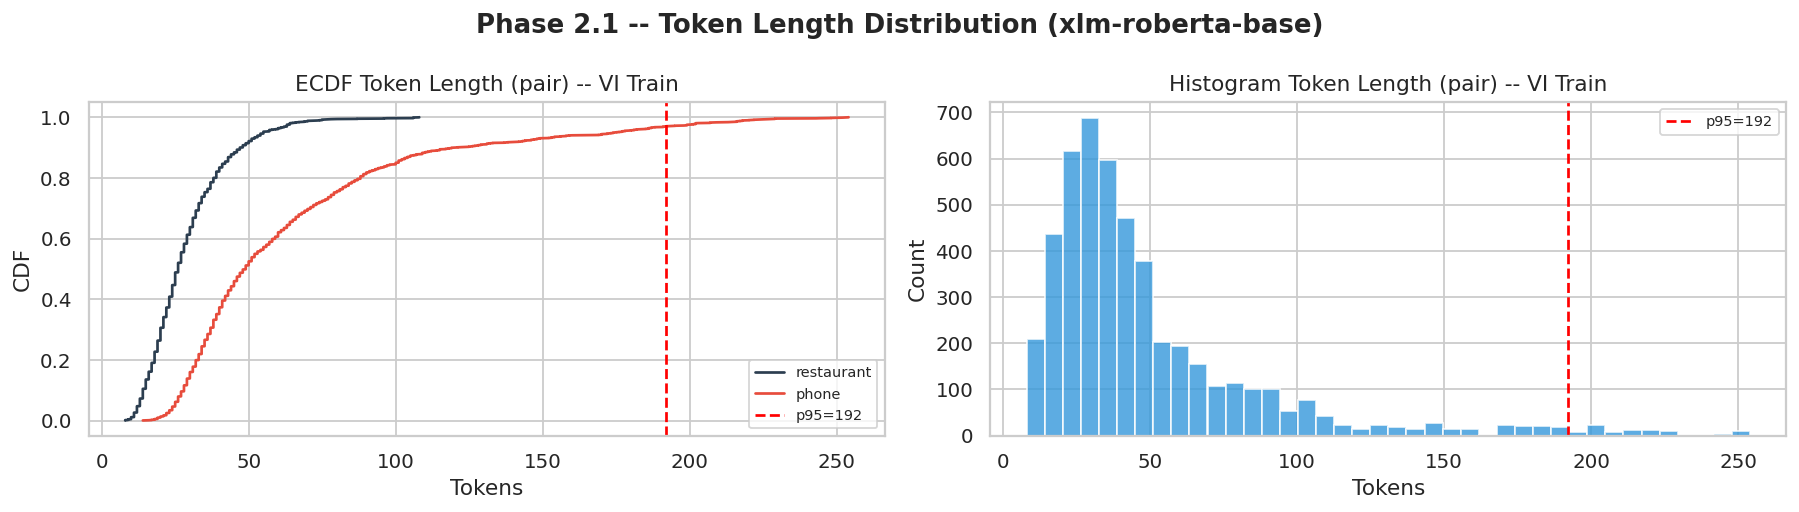

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
for dom, color in zip(DOMAINS, ["#2c3e50","#e74c3c"]):
    vals = np.sort(train_df[train_df["domain"]==dom]["pair_token_len"])
    ax.plot(vals, np.arange(1,len(vals)+1)/len(vals), label=dom, color=color)
ax.axvline(RECOMMENDED_MAX_LENGTH, color="red", ls="--", lw=1.5,
           label=f"p95={RECOMMENDED_MAX_LENGTH}")
ax.set(title="ECDF Token Length (pair) -- VI Train", xlabel="Tokens", ylabel="CDF")
ax.legend(fontsize=8)

ax = axes[1]
ax.hist(train_df["pair_token_len"], bins=40, color="#3498db", alpha=0.8)
ax.axvline(RECOMMENDED_MAX_LENGTH, color="red", ls="--", lw=1.5,
           label=f"p95={RECOMMENDED_MAX_LENGTH}")
ax.set(title="Histogram Token Length (pair) -- VI Train", xlabel="Tokens", ylabel="Count")
ax.legend(fontsize=8)

plt.suptitle("Phase 2.1 -- Token Length Distribution (xlm-roberta-base)",
             fontweight="bold")
plt.tight_layout()
plt.show()

### 2.2 — Label Imbalance Assessment

In [28]:
def label_distribution(sub_df, group_cols):
    counts = (sub_df.groupby(group_cols+["sentiment"])
              .size().rename("count").reset_index())
    pivot = counts.pivot_table(index=group_cols, columns="sentiment",
                               values="count", fill_value=0).reset_index()
    for lbl in ["positive","negative","neutral"]:
        if lbl not in pivot.columns: pivot[lbl] = 0
    pivot["total"] = pivot[["positive","negative","neutral"]].sum(axis=1)
    for lbl in ["positive","negative","neutral"]:
        pivot[f"{lbl}_pct"] = (pivot[lbl]/pivot["total"]*100).round(2)
    pivot["needs_class_weight"] = pivot["neutral_pct"] < NEUTRAL_SAFE_THRESHOLD
    return pivot


label_by_domain = label_distribution(train_df, ["domain"])
print("=== Label Distribution -- VI Train ===")
display(label_by_domain[["domain","positive","negative","neutral","total",
                          "positive_pct","negative_pct","neutral_pct","needs_class_weight"]])

=== Label Distribution -- VI Train ===


sentiment,domain,positive,negative,neutral,total,positive_pct,negative_pct,neutral_pct,needs_class_weight
0,phone,2118.0,646.0,116.0,2880.0,73.54,22.43,4.03,True
1,restaurant,1369.0,558.0,62.0,1989.0,68.83,28.05,3.12,True


In [29]:
def class_weight_table(dist_df, group_cols):
    rows = []
    for _, row in dist_df.iterrows():
        total = row["total"]
        item  = {col: row[col] for col in group_cols}
        for lbl in ["positive","negative","neutral"]:
            cnt = row[lbl]
            item[f"w_{lbl}"] = round(total/(3*cnt),4) if cnt>0 else float("nan")
        rows.append(item)
    return pd.DataFrame(rows)


cw = class_weight_table(label_by_domain, ["domain"])
print("Class Weights (total / (3 x class_count)):")
display(cw)

REQUIRES_CLASS_WEIGHT = bool(label_by_domain["needs_class_weight"].any())
print(f"requires_class_weight = {REQUIRES_CLASS_WEIGHT}")

Class Weights (total / (3 x class_count)):


,domain,w_positive,w_negative,w_neutral
0,phone,0.4533,1.4861,8.2759
1,restaurant,0.4843,1.1882,10.6935


requires_class_weight = True


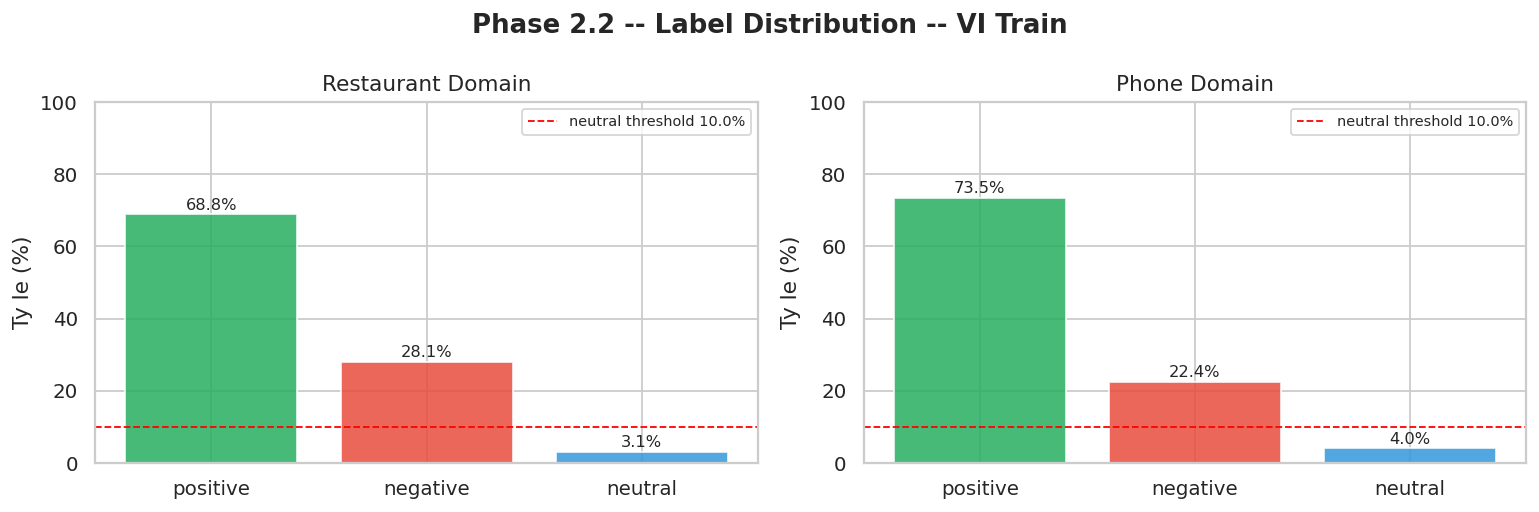

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
lbls   = ["positive","negative","neutral"]
colors = [C[l] for l in lbls]

for ax, dom in zip(axes, DOMAINS):
    row  = label_by_domain[label_by_domain["domain"]==dom].iloc[0]
    pcts = [row[f"{l}_pct"] for l in lbls]
    bars = ax.bar(lbls, pcts, color=colors, alpha=0.85, edgecolor="white")
    ax.axhline(NEUTRAL_SAFE_THRESHOLD, color="red", ls="--", lw=1,
               label=f"neutral threshold {NEUTRAL_SAFE_THRESHOLD}%")
    for bar, pct in zip(bars, pcts):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                f"{pct:.1f}%", ha="center", va="bottom", fontsize=9)
    ax.set(title=f"{dom.capitalize()} Domain", ylabel="Ty le (%)", ylim=(0,100))
    ax.legend(fontsize=8)

plt.suptitle("Phase 2.2 -- Label Distribution -- VI Train", fontweight="bold")
plt.tight_layout()
plt.show()

### 2.3 — Category Sparsity & Mapping Matrix

In [31]:
def category_sparsity(sub_df, domain):
    dom_df = sub_df[sub_df["domain"]==domain]
    counts = (
        dom_df.groupby("aspect_category")
        .agg(n_samples=("sentence_id","count"),
             pos=("sentiment",lambda x:(x=="positive").sum()),
             neg=("sentiment",lambda x:(x=="negative").sum()),
             neu=("sentiment",lambda x:(x=="neutral").sum()))
        .reset_index().sort_values("n_samples",ascending=False)
    )
    counts["is_rare"]     = counts["n_samples"] < RARE_CATEGORY_THRESHOLD
    counts["category_id"] = range(len(counts))
    return counts


cat_rest  = category_sparsity(train_df, "restaurant")
cat_phone = category_sparsity(train_df, "phone")

print(f"Restaurant: {len(cat_rest):3d} categories "
      f"({cat_rest['is_rare'].sum()} rare < {RARE_CATEGORY_THRESHOLD})")
print(f"Phone     : {len(cat_phone):3d} categories "
      f"({cat_phone['is_rare'].sum()} rare < {RARE_CATEGORY_THRESHOLD})")
print("\n--- Restaurant (top 10) ---")
display(cat_rest.head(10))
print("\n--- Phone (top 10) ---")
display(cat_phone.head(10))

Restaurant:  12 categories (1 rare < 20)
Phone     :  84 categories (43 rare < 20)

--- Restaurant (top 10) ---


,aspect_category,n_samples,pos,neg,neu,is_rare,category_id
5,food quality,693,495,174,24,False,0
11,service general,356,196,157,3,False,1
8,restaurant general,308,240,62,6,False,2
0,ambience general,222,171,43,8,False,3
6,food style_options,97,62,29,6,False,4
9,restaurant miscellaneous,81,52,23,6,False,5
4,food prices,62,31,29,2,False,6
10,restaurant prices,61,27,30,4,False,7
2,drinks quality,40,37,3,0,False,8
3,drinks style_options,30,27,3,0,False,9



--- Phone (top 10) ---


,aspect_category,n_samples,pos,neg,neu,is_rare,category_id
36,overall#overall,546,457,88,1,False,0
35,logistics#speed,240,198,27,15,False,1
33,logistics#lost and damaged,153,132,12,9,False,2
20,buyer attitude#recommendable,124,82,42,0,False,3
40,price#price,92,79,12,1,False,4
26,camera#general,84,52,30,2,False,5
64,seller service#attitude,77,66,11,0,False,6
57,product quality#general,76,62,13,1,False,7
12,battery/longevity#battery life,65,54,11,0,False,8
68,seller service#timeliness of seller service,62,59,3,0,False,9


In [32]:
cat_rest_map  = {r["aspect_category"]:r["category_id"] for _,r in cat_rest.iterrows()}
cat_phone_map = {r["aspect_category"]:r["category_id"] for _,r in cat_phone.iterrows()}
category_maps = {"restaurant":cat_rest_map,"phone":cat_phone_map}

cat_map_path = PROCESSED_DIR / "category_maps.json"
with open(cat_map_path,"w",encoding="utf-8") as f:
    json.dump(category_maps, f, ensure_ascii=False, indent=2)
print(f"Saved category maps -> {cat_map_path}")
print(f"Restaurant: {len(cat_rest_map)} cats | Phone: {len(cat_phone_map)} cats")

Saved category maps -> data/processed/vi/category_maps.json
Restaurant: 12 cats | Phone: 84 cats


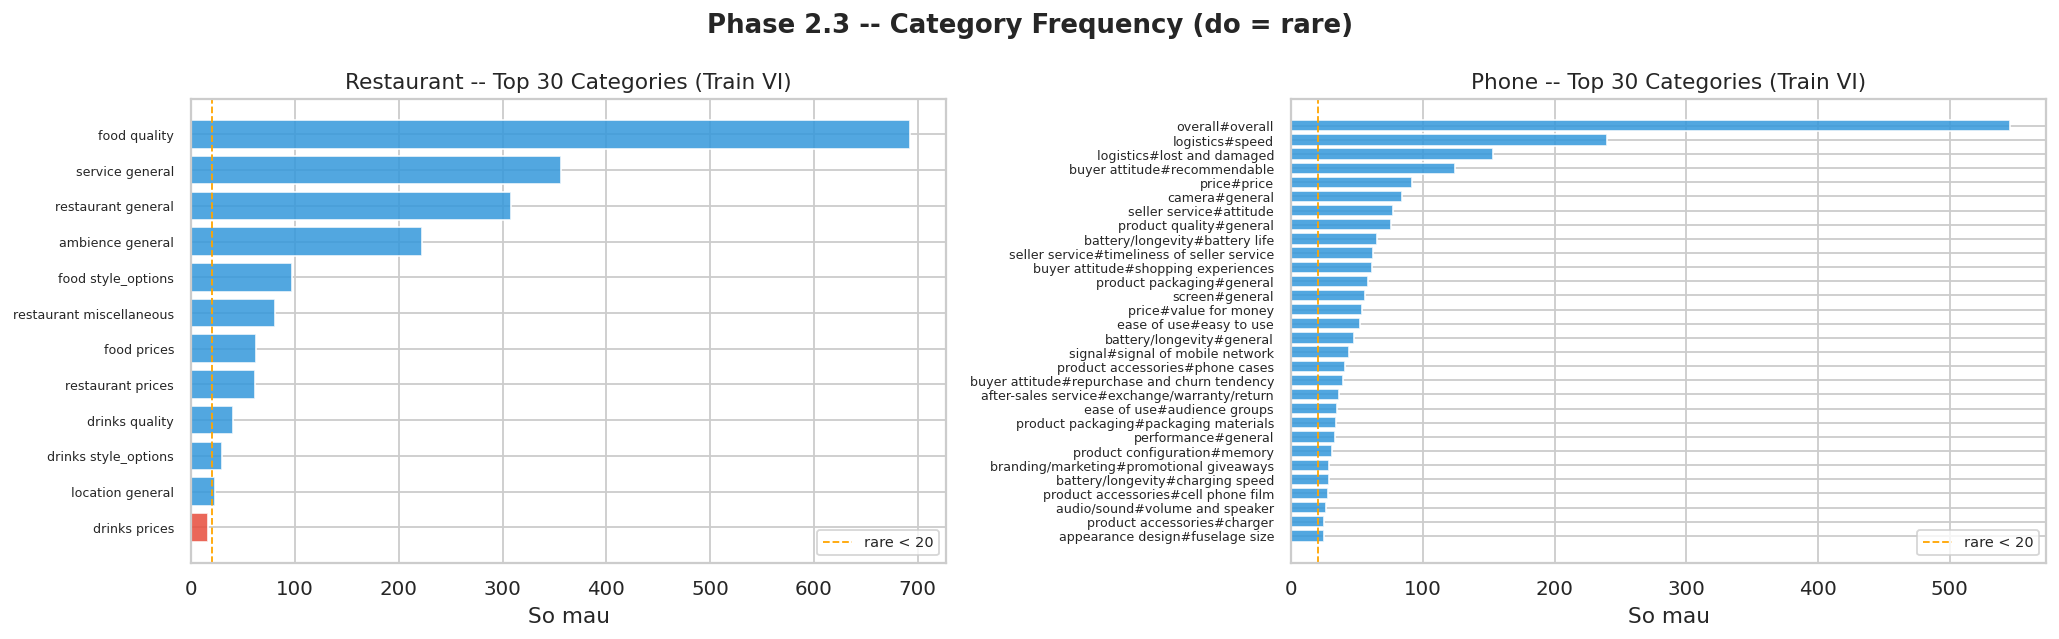

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, (cat_df, dom) in zip(axes, [(cat_rest,"restaurant"),(cat_phone,"phone")]):
    top = cat_df.head(30)
    bar_colors = ["#e74c3c" if r else "#3498db" for r in top["is_rare"]]
    ax.barh(top["aspect_category"][::-1], top["n_samples"][::-1],
            color=bar_colors[::-1], alpha=0.85)
    ax.axvline(RARE_CATEGORY_THRESHOLD, color="orange", ls="--", lw=1,
               label=f"rare < {RARE_CATEGORY_THRESHOLD}")
    ax.set(title=f"{dom.capitalize()} -- Top 30 Categories (Train VI)",
           xlabel="So mau")
    ax.legend(fontsize=8)
    ax.tick_params(axis="y", labelsize=7)
plt.suptitle("Phase 2.3 -- Category Frequency (do = rare)", fontweight="bold")
plt.tight_layout()
plt.show()

---
# 🔬 PHASE 3 — MICRO-LINGUISTIC & TRANSLATIONESE ARTIFACT ANALYSIS (Train only)

Dinh luong loi dich may VI:
- `attention_mask_strategy`: `dynamic` vs `standard`
- `recommended_dropout`: tang theo artifact rate

**3.1** Phat hien pronoun injection trong NULL aspect samples  
**3.2** Do ti le n-gram cung nhac quanh aspect term

### 3.1 — Implicit NULL Aspect: Pronoun Injection

In [34]:
VI_INJECTION_TOKENS = {
    "pronoun"     : ["toi","chung toi","ho","no","bon ho",
                     "anh","chi","em","ban","minh","chung ta"],
    "copula"      : ["day la","do la","nay la","la","day"],
    "nominalizer" : ["viec","dieu","su"],
    "intensifier" : ["that la","that su","qua that","ro rang la","thuc su"],
    "existential" : ["co","khong co"],
}


def simple_tokenize(text: str):
    return re.findall(r"[\w]+|[^\s\w]", text.lower())


def detect_injection(text: str, inject_dict: dict, window: int = 6):
    """Scan first `window` tokens for injection patterns."""
    tokens = simple_tokenize(text)[:window]
    found_cats, found_toks = [], []
    for cat, inject_list in inject_dict.items():
        for phrase in inject_list:
            pt = phrase.split()
            for i in range(len(tokens)-len(pt)+1):
                if tokens[i:i+len(pt)] == pt:
                    found_cats.append(cat)
                    found_toks.append(phrase)
                    break
    return bool(found_cats), list(set(found_cats)), list(set(found_toks))


print("Injection detector defined.")

Injection detector defined.


In [35]:
implicit_train = train_df[train_df["is_implicit"]].copy()
print(f"Implicit (NULL) samples -- Train VI: {len(implicit_train):,}")
print(f"  Restaurant: {len(implicit_train[implicit_train.domain=='restaurant']):,}")
print(f"  Phone     : {len(implicit_train[implicit_train.domain=='phone']):,}")

inj_res = implicit_train["text"].apply(
    lambda t: detect_injection(t, VI_INJECTION_TOKENS)
)
implicit_train = implicit_train.copy()
implicit_train["has_injection"] = [r[0] for r in inj_res]
implicit_train["inject_cats"]   = [r[1] for r in inj_res]
implicit_train["inject_tokens"] = [r[2] for r in inj_res]

n_total  = len(implicit_train)
n_inject = int(implicit_train["has_injection"].sum())
inj_rate = n_inject/n_total*100 if n_total > 0 else 0.0

print(f"\nInjection rate (NULL): {n_inject}/{n_total} = {inj_rate:.1f}%")

Implicit (NULL) samples -- Train VI: 495
  Restaurant: 495
  Phone     : 0

Injection rate (NULL): 8/495 = 1.6%


In [36]:
all_cats = [c for cats in implicit_train["inject_cats"] for c in cats]
inj_breakdown = pd.DataFrame(
    Counter(all_cats).most_common(), columns=["injection_type","count"]
)
print("Injection breakdown:")
display(inj_breakdown)

print("\nVi du cau co injection:")
display(
    implicit_train[implicit_train["has_injection"]]
    [["domain","text","inject_tokens","sentiment"]].head(8)
)

ATTENTION_MASK_STRATEGY = "dynamic" if inj_rate >= 20 else "standard"
print(f"\n-> attention_mask_strategy = '{ATTENTION_MASK_STRATEGY}'")

Injection breakdown:


,injection_type,count
0,pronoun,5
1,copula,3



Vi du cau co injection:


,domain,text,inject_tokens,sentiment
359,restaurant,"Chồng tôi nói anh ấy có thể ăn thêm vài phần nữa, phần đối với tôi là ổn, anh ấy thậm chí còn thốt lên rằng phần kho...",[anh],negative
360,restaurant,"Chồng tôi nói anh ấy có thể ăn thêm vài phần nữa, phần đối với tôi là ổn, anh ấy thậm chí còn thốt lên rằng phần kho...",[anh],positive
447,restaurant,"Phản ứng của anh ta là tự mãn, kiêu ngạo và hạ thấp người khác, hoàn toàn phù hợp với thái độ mà anh ta thể hiện suố...",[anh],negative
448,restaurant,"Phản ứng của anh ta là tự mãn, kiêu ngạo và hạ thấp người khác, hoàn toàn phù hợp với thái độ mà anh ta thể hiện suố...",[anh],negative
449,restaurant,"Phản ứng của anh ta là tự mãn, kiêu ngạo và hạ thấp người khác, hoàn toàn phù hợp với thái độ mà anh ta thể hiện suố...",[anh],negative
1089,restaurant,"Giá là 14 đô la, không tệ cho một pound Pastrami - nhưng nó không có nhiều hương vị - tôi đã từng ăn ngon hơn với gi...",[la],neutral
1090,restaurant,"Giá là 14 đô la, không tệ cho một pound Pastrami - nhưng nó không có nhiều hương vị - tôi đã từng ăn ngon hơn với gi...",[la],negative
1143,restaurant,170 đô la xuống bồn cầu ...,[la],negative



-> attention_mask_strategy = 'standard'


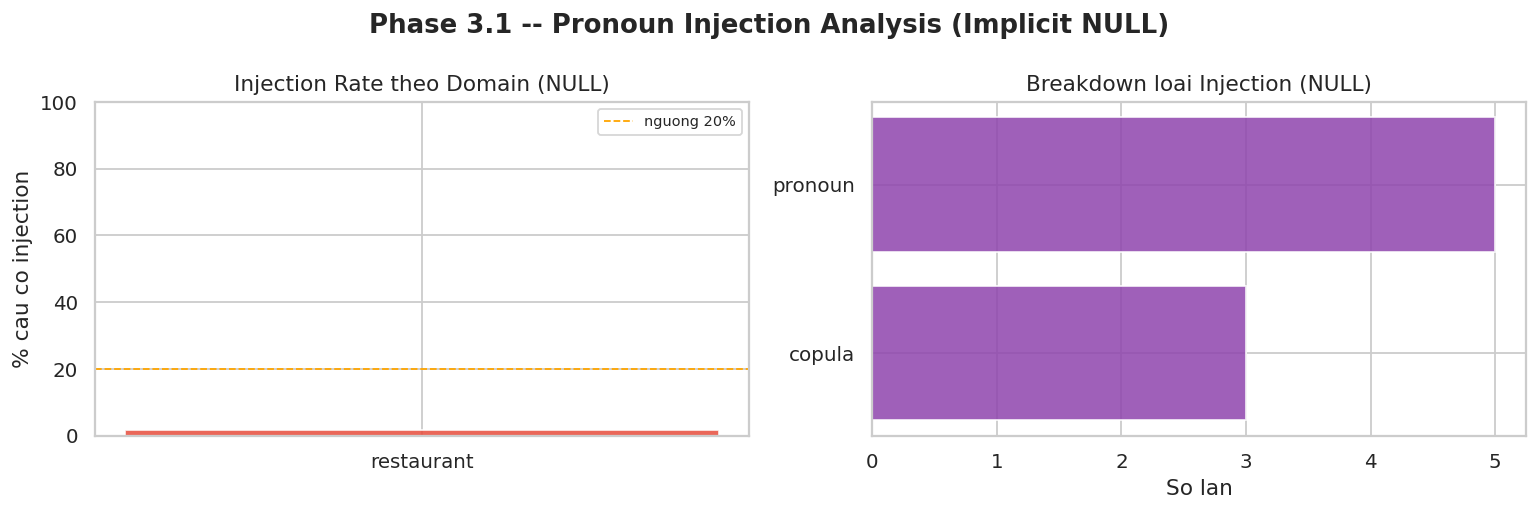

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
dom_inj = (
    implicit_train.groupby("domain")["has_injection"]
    .agg(["mean","sum","count"])
    .assign(rate_pct=lambda x: x["mean"]*100)
)
ax.bar(dom_inj.index, dom_inj["rate_pct"],
       color=["#e74c3c","#3498db"], alpha=0.85)
ax.axhline(20, color="orange", ls="--", lw=1, label="nguong 20%")
ax.set(title="Injection Rate theo Domain (NULL)",
       ylabel="% cau co injection", ylim=(0,100))
ax.legend(fontsize=8)

ax = axes[1]
if len(inj_breakdown) > 0 and inj_breakdown["count"].sum() > 0:
    ax.barh(inj_breakdown["injection_type"][::-1],
            inj_breakdown["count"][::-1], color="#8e44ad", alpha=0.85)
    ax.set(title="Breakdown loai Injection (NULL)", xlabel="So lan")
else:
    ax.text(0.5,0.5,"Khong phat hien injection",ha="center",va="center",
            transform=ax.transAxes)
    ax.set_title("Injection (khong co)")

plt.suptitle("Phase 3.1 -- Pronoun Injection Analysis (Implicit NULL)", fontweight="bold")
plt.tight_layout()
plt.show()

### 3.2 — Translationese Artifact Rate

In [38]:
SEVERITY_SCORE = {"HIGH": 3, "MED": 2, "LOW": 1}

VI_ARTIFACT_PATTERNS = {
    "thi"       : ("copula_bridge","HIGH","Cau noi copula -- overused boi MT"),
    "thi la"    : ("double_copula","HIGH","Double copula -- hiem trong native VI"),
    "la"        : ("copula",       "MED", "Copula them vao sau aspect"),
    "su"        : ("nominalizer",  "MED", "Tien to su (the X -> su X)"),
    "dieu"      : ("nominalizer",  "MED", "Abstract nominalizer injection"),
    "viec"      : ("nominalizer",  "MED", "Gerund nominalizer injection"),
    "cua no"    : ("possessive",   "HIGH","Pronoun possessive -- khong tu nhien trong review"),
    "cua ho"    : ("possessive",   "MED", "Third-person possessive injection"),
    "that su"   : ("intensifier",  "LOW", "Intensifier overused boi MT"),
    "rat la"    : ("intensifier",  "LOW", "Stacked intensifier"),
    "hoan toan" : ("intensifier",  "LOW", "Completely -- dich qua literal"),
    "noi chung" : ("filler",       "LOW", "Discourse filler them boi MT"),
    "thuc ra"   : ("filler",       "LOW", "Actually injection"),
    "duoc"      : ("passive",      "MED", "Passive marker -- MT artifact"),
    "bi"        : ("passive",      "MED", "Adverse passive -- MT artifact"),
}
print(f"Artifact patterns: {len(VI_ARTIFACT_PATTERNS)}")

Artifact patterns: 15


In [39]:
def extract_ngram_window(text, aspect_term, window=3, n=2):
    if not aspect_term or aspect_term.upper() == "NULL":
        return [], [], -1
    tokens   = simple_tokenize(text)
    asp_toks = simple_tokenize(aspect_term)
    pos      = -1
    for i in range(len(tokens)-len(asp_toks)+1):
        if tokens[i:i+len(asp_toks)] == asp_toks:
            pos = i; break
    if pos < 0:
        return [], [], -1
    pre  = tokens[max(0,pos-window):pos]
    post = tokens[pos+len(asp_toks):pos+len(asp_toks)+window]
    def mkng(toks, n):
        out = []
        for k in range(1,n+1):
            out += [" ".join(toks[i:i+k]) for i in range(len(toks)-k+1)]
        return out
    return mkng(pre,n), mkng(post,n), pos


def score_artifacts(ngrams, pattern_dict):
    score, found = 0, []
    for ng in set(ngrams):
        if ng in pattern_dict:
            atype, severity, desc = pattern_dict[ng]
            score += SEVERITY_SCORE[severity]
            found.append((ng, atype, severity))
    return score, found


print("N-gram extractor & artifact scorer defined.")

N-gram extractor & artifact scorer defined.


In [40]:
explicit_train = train_df[~train_df["is_implicit"]].copy()
print(f"Explicit (non-NULL) train samples: {len(explicit_train):,}")

ngram_data = []
for _, row in explicit_train.iterrows():
    pre, post, pos = extract_ngram_window(row["text"], row["aspect_term"])
    score, found   = score_artifacts(pre+post, VI_ARTIFACT_PATTERNS)
    ngram_data.append({
        "sentence_id"    : row["sentence_id"],
        "domain"         : row["domain"],
        "aspect_term"    : row["aspect_term"],
        "aspect_category": row["aspect_category"],
        "sentiment"      : row["sentiment"],
        "artifact_score" : score,
        "artifact_found" : found,
        "is_artifact"    : (score > 0),
    })

ngram_df      = pd.DataFrame(ngram_data)
ARTIFACT_RATE = ngram_df["is_artifact"].mean() if len(ngram_df) else 0.0
print(f"Artifact Rate: {ngram_df['is_artifact'].sum()}/{len(ngram_df)} = {ARTIFACT_RATE*100:.1f}%")

Explicit (non-NULL) train samples: 4,374
Artifact Rate: 13/4374 = 0.3%


In [41]:
art_by_domain = (
    ngram_df.groupby("domain")["is_artifact"]
    .agg(artifact_count="sum", total="count")
    .assign(artifact_rate=lambda x: (x["artifact_count"]/x["total"]).round(4))
    .reset_index()
)
display(art_by_domain)

all_found = [(ng,at,sv) for fl in ngram_df["artifact_found"] for (ng,at,sv) in fl]
patt_cnt  = Counter(ng for ng,_,_ in all_found)
sev_order = {"HIGH":0,"MED":1,"LOW":2}

art_ref_df = pd.DataFrame([
    {"pattern":ng,"type":at,"severity":sv,"freq":patt_cnt.get(ng,0),"desc":dsc}
    for ng,(at,sv,dsc) in VI_ARTIFACT_PATTERNS.items()
]).sort_values(
    ["severity","freq"],
    key=lambda s: s.map(sev_order) if s.name=="severity" else -s
).reset_index(drop=True)

print("\n=== Artifact Pattern Reference Table ===")
display(art_ref_df)

,domain,artifact_count,total,artifact_rate
0,phone,4,2880,0.0014
1,restaurant,9,1494,0.0060



=== Artifact Pattern Reference Table ===


,pattern,type,severity,freq,desc
0,thi,copula_bridge,HIGH,0,Cau noi copula -- overused boi MT
1,thi la,double_copula,HIGH,0,Double copula -- hiem trong native VI
2,cua no,possessive,HIGH,0,Pronoun possessive -- khong tu nhien trong review
3,la,copula,MED,11,Copula them vao sau aspect
4,su,nominalizer,MED,2,Tien to su (the X -> su X)
5,dieu,nominalizer,MED,0,Abstract nominalizer injection
6,viec,nominalizer,MED,0,Gerund nominalizer injection
7,cua ho,possessive,MED,0,Third-person possessive injection
8,duoc,passive,MED,0,Passive marker -- MT artifact
9,bi,passive,MED,0,Adverse passive -- MT artifact


In [42]:
def map_dropout(rate, dmap):
    for threshold, dropout in sorted(dmap, reverse=True):
        if rate >= threshold: return dropout
    return dmap[-1][1]


RECOMMENDED_DROPOUT = map_dropout(ARTIFACT_RATE, DROPOUT_MAP)
print(f"Artifact Rate    = {ARTIFACT_RATE*100:.1f}%")
print(f"recommended_dropout = {RECOMMENDED_DROPOUT}")

Artifact Rate    = 0.3%
recommended_dropout = 0.1


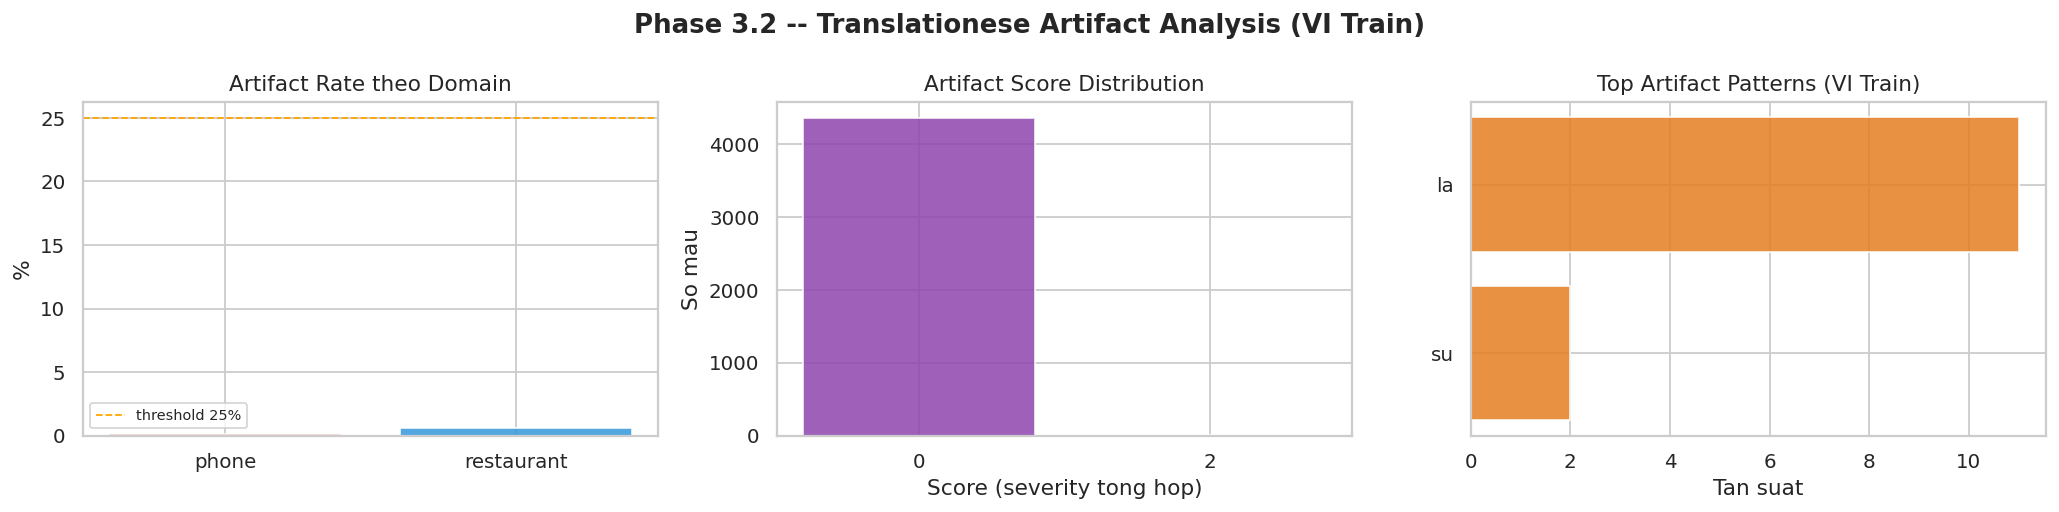

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

ax = axes[0]
ax.bar(art_by_domain["domain"], art_by_domain["artifact_rate"]*100,
       color=["#e74c3c","#3498db"], alpha=0.85)
ax.axhline(ARTIFACT_HIGH_THRESHOLD*100, color="orange", ls="--", lw=1,
           label=f"threshold {ARTIFACT_HIGH_THRESHOLD*100:.0f}%")
ax.set(title="Artifact Rate theo Domain", ylabel="%")
ax.legend(fontsize=8)

ax = axes[1]
sc = ngram_df["artifact_score"].value_counts().sort_index()
ax.bar(sc.index.astype(str), sc.values, color="#8e44ad", alpha=0.85)
ax.set(title="Artifact Score Distribution",
       xlabel="Score (severity tong hop)", ylabel="So mau")

ax = axes[2]
top_pat = art_ref_df[art_ref_df["freq"]>0].head(10)
if len(top_pat):
    ax.barh(top_pat["pattern"][::-1], top_pat["freq"][::-1],
            color="#e67e22", alpha=0.85)
    ax.set(title="Top Artifact Patterns (VI Train)", xlabel="Tan suat")
else:
    ax.text(0.5,0.5,"Khong co artifact",ha="center",va="center",
            transform=ax.transAxes)
    ax.set_title("Top Artifact Patterns")

plt.suptitle("Phase 3.2 -- Translationese Artifact Analysis (VI Train)", fontweight="bold")
plt.tight_layout()
plt.show()

---
# 📊 PHASE 4 — CROSS-SPLIT COVARIATE SHIFT & SPLIT INTEGRITY

> **Mo ca 3 tap Train / Val / Test**

- 4.1 Split Integrity
- 4.2 Category Overlap & Unseen Audit
- 4.3 Sentiment Distribution Shift (TVD)

In [44]:
all_splits_df = df[df["is_valid_sent"]].copy()
print(f"Tong ban ghi hop le (3 splits): {len(all_splits_df):,}")
print(all_splits_df.groupby(["domain","split"]).size().unstack(fill_value=0))

Tong ban ghi hop le (3 splits): 8,100
split       dev  test  training
domain                         
phone       710  1215      2880
restaurant  507   799      1989


### 4.1 — Split Integrity

In [45]:
integrity = []
for domain in DOMAINS:
    for split in SPLITS:
        sub   = all_splits_df[(all_splits_df["domain"]==domain) &
                              (all_splits_df["split"]==split)]
        n_sent = sub["sentence_id"].nunique()
        n_trip = len(sub)
        integrity.append({"domain":domain,"split":split,
                          "n_sentences":n_sent,"n_triplets":n_trip,
                          "avg_trip":round(n_trip/n_sent,2) if n_sent else 0})

integrity_df = pd.DataFrame(integrity)
print("=== Split Integrity -- VI ===")
display(integrity_df.pivot_table(
    index="domain",columns="split",
    values=["n_sentences","n_triplets"],fill_value=0
))

print("\nTy le phan chia (theo so cau):")
for domain in DOMAINS:
    dom   = integrity_df[integrity_df["domain"]==domain].set_index("split")
    total = dom["n_sentences"].sum()
    ratios= (dom["n_sentences"]/total*100).round(1)
    print(f"  {domain}: " + "  ".join(f"{s}={ratios.get(s,0):.1f}%" for s in SPLITS))

=== Split Integrity -- VI ===


n_sentences                 n_triplets                 
split              dev   test training        dev    test training
domain                                                            
phone            256.0  449.0   1073.0      710.0  1215.0   2880.0
restaurant       316.0  544.0   1264.0      507.0   799.0   1989.0


Ty le phan chia (theo so cau):
  restaurant: training=59.5%  dev=14.9%  test=25.6%
  phone: training=60.3%  dev=14.4%  test=25.3%


### 4.2 — Category Overlap & Unseen Category Audit

In [46]:
def unseen_category_audit(df_all, domain):
    sub  = df_all[df_all["domain"]==domain]
    cats = {s: set(sub.loc[sub["split"]==s,"aspect_category"]) for s in SPLITS}
    tr   = cats["training"]
    return {
        "domain"        : domain,
        "train_cats"    : len(tr),
        "val_cats"      : len(cats["dev"]),
        "test_cats"     : len(cats["test"]),
        "val_unseen_n"  : len(cats["dev"]  - tr),
        "test_unseen_n" : len(cats["test"] - tr),
        "val_unseen"    : sorted(cats["dev"]  - tr),
        "test_unseen"   : sorted(cats["test"] - tr),
    }


overlap_results = [unseen_category_audit(all_splits_df, d) for d in DOMAINS]
overlap_df      = pd.DataFrame(overlap_results)

print("=== Category Overlap Audit ===")
display(overlap_df[["domain","train_cats","val_cats","test_cats",
                     "val_unseen_n","test_unseen_n"]])

for r in overlap_results:
    if r["test_unseen_n"] > 0:
        print(f"\n[WARN] {r['domain'].upper()}: {r['test_unseen_n']} cate CHUA THAY o Train:")
        for cat in r["test_unseen"]: print(f"  - {cat}")
    else:
        print(f"\n[OK]   {r['domain'].upper()}: Khong co unseen category trong Test.")

=== Category Overlap Audit ===


,domain,train_cats,val_cats,test_cats,val_unseen_n,test_unseen_n
0,restaurant,12,13,12,1,0
1,phone,84,74,76,2,1



[OK]   RESTAURANT: Khong co unseen category trong Test.

[WARN] PHONE: 1 cate CHUA THAY o Train:
  - product packaging#instruction manual


### 4.3 — Sentiment Distribution Shift (TVD)

In [47]:
LABEL_KEYS = ["positive","negative","neutral"]


def norm_counter(counter, keys):
    total = sum(counter.get(k,0) for k in keys)
    return {k: counter.get(k,0)/total if total else 0.0 for k in keys}


def tvd(p, q, keys):
    return 0.5 * sum(abs(p.get(k,0)-q.get(k,0)) for k in keys)


shift_rows = []
for domain in DOMAINS:
    sub   = all_splits_df[all_splits_df["domain"]==domain]
    train = sub[sub["split"]=="training"]
    val   = sub[sub["split"]=="dev"]
    test  = sub[sub["split"]=="test"]
    p_tr  = norm_counter(Counter(train["sentiment"]),LABEL_KEYS)
    p_val = norm_counter(Counter(val["sentiment"]),  LABEL_KEYS)
    p_te  = norm_counter(Counter(test["sentiment"]), LABEL_KEYS)
    tr_t  = set(train["text"]); val_t = set(val["text"]); te_t = set(test["text"])
    shift_rows.append({
        "domain"            : domain,
        "tvd_train_val"     : round(tvd(p_tr,p_val,LABEL_KEYS),4),
        "tvd_train_test"    : round(tvd(p_tr,p_te, LABEL_KEYS),4),
        "train_pos_pct"     : round(p_tr["positive"]*100,1),
        "train_neg_pct"     : round(p_tr["negative"]*100,1),
        "train_neu_pct"     : round(p_tr["neutral"] *100,1),
        "test_pos_pct"      : round(p_te["positive"]*100,1),
        "test_neg_pct"      : round(p_te["negative"]*100,1),
        "test_neu_pct"      : round(p_te["neutral"] *100,1),
        "train_val_overlap" : len(tr_t & val_t),
        "train_test_overlap": len(tr_t & te_t),
    })

shift_df = pd.DataFrame(shift_rows)
print("=== Covariate Shift Summary -- VI ===")
display(shift_df)

=== Covariate Shift Summary -- VI ===


,domain,tvd_train_val,tvd_train_test,train_pos_pct,train_neg_pct,train_neu_pct,test_pos_pct,test_neg_pct,test_neu_pct,train_val_overlap,train_test_overlap
0,restaurant,0.0157,0.0603,68.8,28.1,3.1,73.0,22.0,5.0,1,4
1,phone,0.0173,0.0103,73.5,22.4,4.0,74.6,21.6,3.8,0,0


In [48]:
for _, row in shift_df.iterrows():
    dom = row["domain"]
    if row["train_test_overlap"] > 0:
        print(f"[WARN] {dom}: {row['train_test_overlap']} cau trung Train<->Test (data leakage!)")
    else:
        print(f"[OK]   {dom}: Khong co text overlap Train<->Test.")
    tvd_v = row["tvd_train_test"]
    marker = "WARN" if tvd_v > 0.05 else "OK"
    print(f"  [{marker}] TVD(train,test) = {tvd_v:.4f}", end="")
    print(" -- can xem lai" if tvd_v > 0.05 else " -- on dinh")

[WARN] restaurant: 4 cau trung Train<->Test (data leakage!)
  [WARN] TVD(train,test) = 0.0603 -- can xem lai
[OK]   phone: Khong co text overlap Train<->Test.
  [OK] TVD(train,test) = 0.0103 -- on dinh


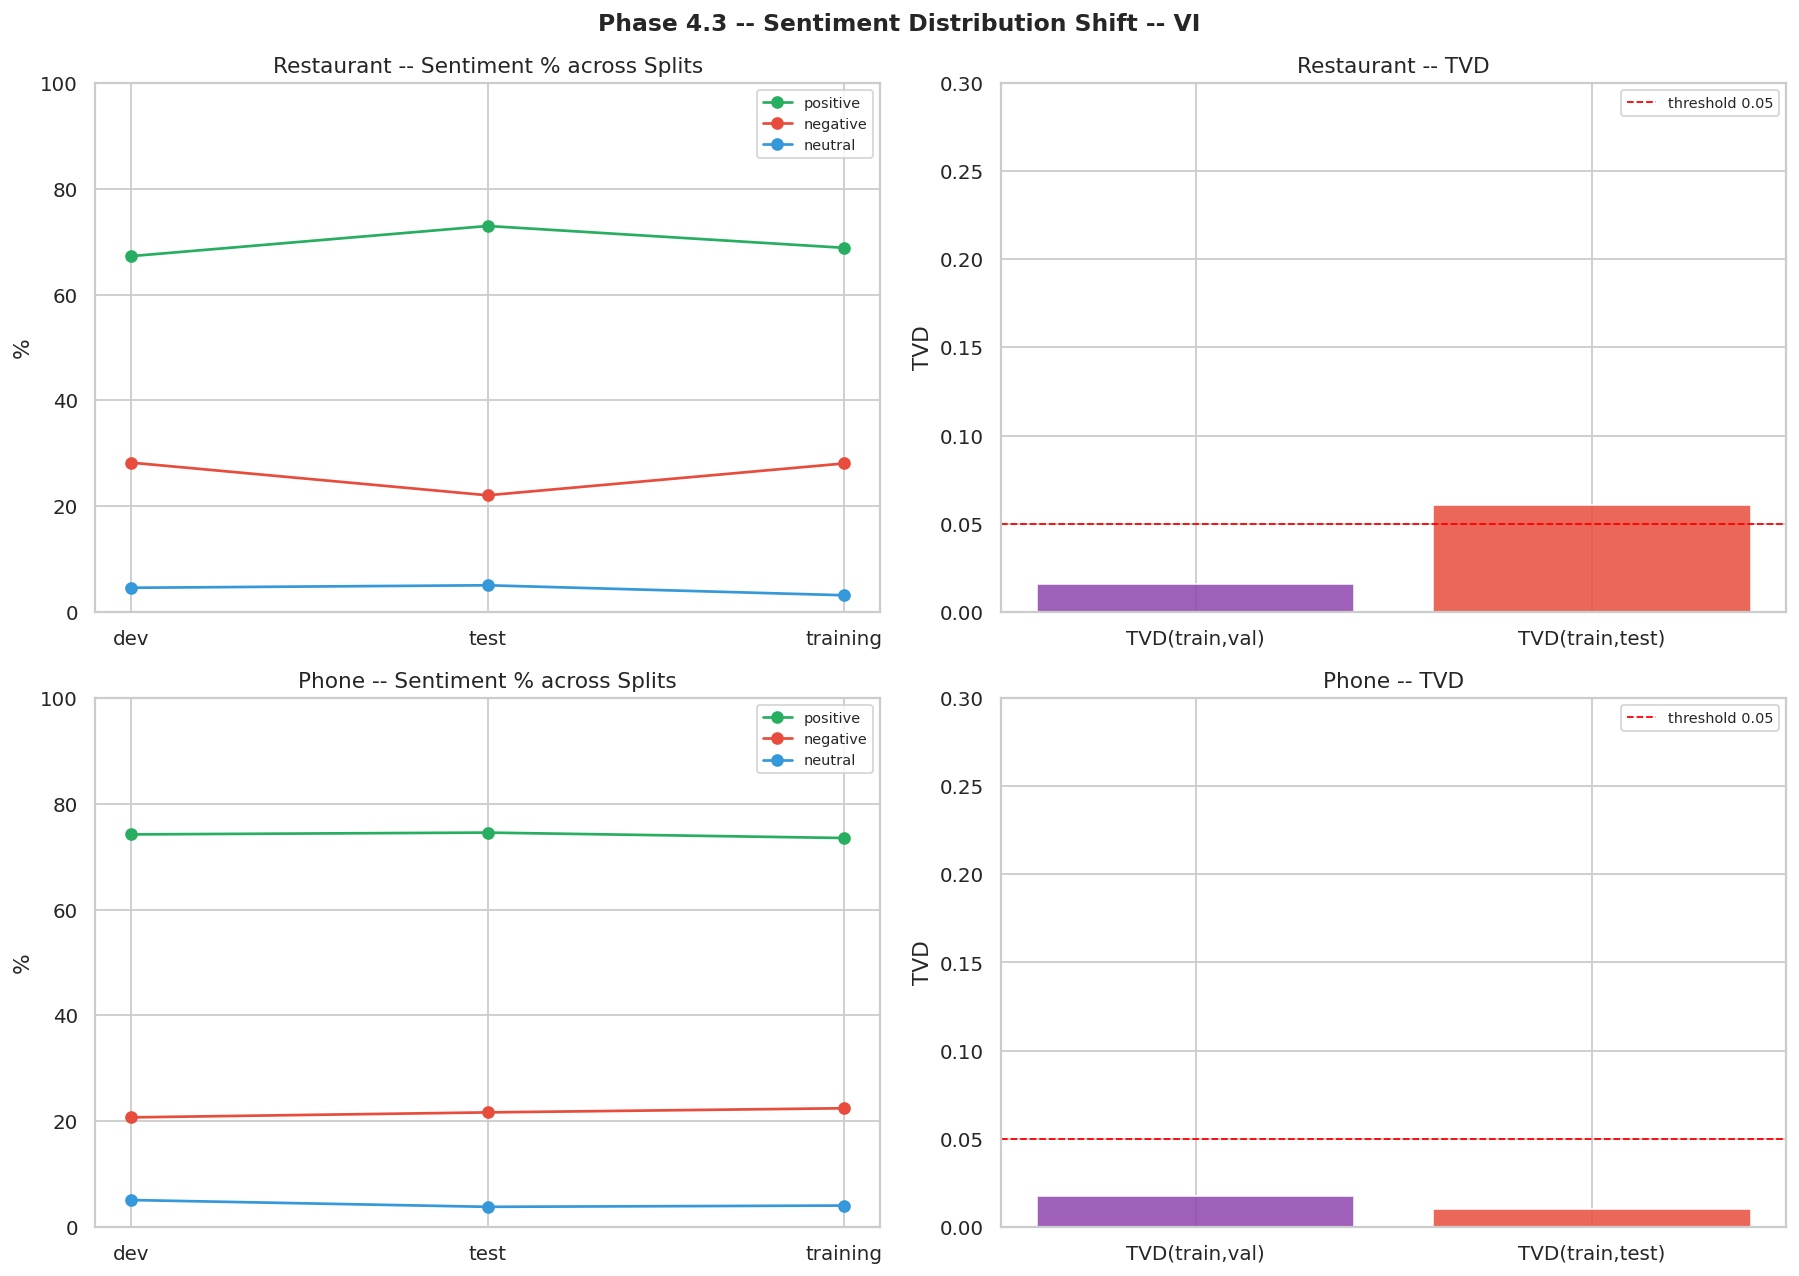

In [49]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for row_i, domain in enumerate(DOMAINS):
    sub = all_splits_df[all_splits_df["domain"]==domain]

    ax = axes[row_i][0]
    spl = (sub.groupby(["split","sentiment"]).size().rename("n").reset_index())
    spl["pct"] = spl.groupby("split")["n"].transform(lambda x: x/x.sum()*100)
    for lbl in LABEL_KEYS:
        s = spl[spl["sentiment"]==lbl]
        ax.plot(s["split"], s["pct"], marker="o", label=lbl, color=C[lbl])
    ax.set(title=f"{domain.capitalize()} -- Sentiment % across Splits",
           ylabel="%", ylim=(0,100))
    ax.legend(fontsize=8)

    ax = axes[row_i][1]
    dom_row = shift_df[shift_df["domain"]==domain].iloc[0]
    ax.bar(["TVD(train,val)","TVD(train,test)"],
           [dom_row["tvd_train_val"],dom_row["tvd_train_test"]],
           color=["#8e44ad","#e74c3c"], alpha=0.85)
    ax.axhline(0.05, color="red", ls="--", lw=1, label="threshold 0.05")
    ax.set(title=f"{domain.capitalize()} -- TVD", ylabel="TVD", ylim=(0,0.3))
    ax.legend(fontsize=8)

plt.suptitle("Phase 4.3 -- Sentiment Distribution Shift -- VI",
             fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()

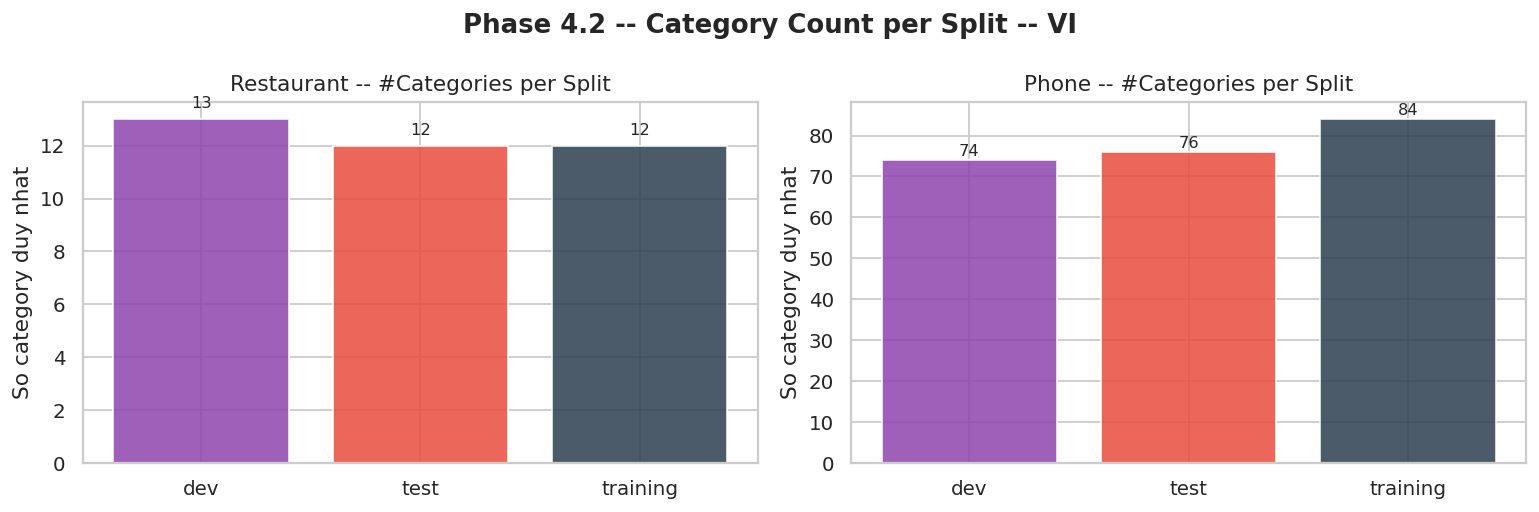

In [50]:
cat_per_split = (
    all_splits_df.groupby(["domain","split"])["aspect_category"]
    .nunique().rename("n_cats").reset_index()
)
split_colors = {"training":C["train"],"dev":C["val"],"test":C["test"]}
fig, axes = plt.subplots(1,2,figsize=(12,4))
for ax, domain in zip(axes, DOMAINS):
    sub  = cat_per_split[cat_per_split["domain"]==domain]
    bars = ax.bar(sub["split"],sub["n_cats"],
                  color=[split_colors.get(s,"gray") for s in sub["split"]], alpha=0.85)
    for bar, row in zip(bars, sub.itertuples()):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                str(row.n_cats), ha="center", va="bottom", fontsize=9)
    ax.set(title=f"{domain.capitalize()} -- #Categories per Split",
           ylabel="So category duy nhat")
plt.suptitle("Phase 4.2 -- Category Count per Split -- VI", fontweight="bold")
plt.tight_layout()
plt.show()

---
# 🏁 PHASE 5 — MODEL CONFIGURATION SUMMARY

Dong goi toan bo phat hien dinh luong tu Phase 2, 3, 4 thanh **Config Dictionary** dung cho pipeline huan luyen.

In [51]:
high_tvd_domains   = [r["domain"] for _,r in shift_df.iterrows() if r["tvd_train_test"]>0.05]
leakage_domains    = [r["domain"] for _,r in shift_df.iterrows() if r["train_test_overlap"]>0]
unseen_cat_domains = [r["domain"] for r in overlap_results if r["test_unseen_n"]>0]

model_signals = {
    "language"                    : TARGET_LANG,
    "tokenizer"                   : TOKENIZER_NAME,
    # Phase 2.1
    "recommended_max_length"      : RECOMMENDED_MAX_LENGTH,
    "token_p90_restaurant"        : int(len_by_domain.loc[len_by_domain["domain"]=="restaurant","p90"].iloc[0]),
    "token_p95_restaurant"        : int(len_by_domain.loc[len_by_domain["domain"]=="restaurant","p95"].iloc[0]),
    "token_p90_phone"             : int(len_by_domain.loc[len_by_domain["domain"]=="phone","p90"].iloc[0]),
    "token_p95_phone"             : int(len_by_domain.loc[len_by_domain["domain"]=="phone","p95"].iloc[0]),
    # Phase 2.2
    "requires_class_weight"       : REQUIRES_CLASS_WEIGHT,
    "class_weights"               : {
        row["domain"]: {
            "positive": float(cw.loc[cw["domain"]==row["domain"],"w_positive"].iloc[0]),
            "negative": float(cw.loc[cw["domain"]==row["domain"],"w_negative"].iloc[0]),
            "neutral" : float(cw.loc[cw["domain"]==row["domain"],"w_neutral"].iloc[0]),
        }
        for _,row in label_by_domain.iterrows()
    },
    # Phase 2.3
    "n_categories_restaurant"     : int(len(cat_rest)),
    "n_rare_categories_restaurant": int(cat_rest["is_rare"].sum()),
    "n_categories_phone"          : int(len(cat_phone)),
    "n_rare_categories_phone"     : int(cat_phone["is_rare"].sum()),
    # Phase 3.1
    "implicit_injection_rate"     : round(inj_rate/100, 4),
    "attention_mask_strategy"     : ATTENTION_MASK_STRATEGY,
    # Phase 3.2
    "artifact_rate"               : round(ARTIFACT_RATE, 4),
    "recommended_dropout"         : RECOMMENDED_DROPOUT,
    # Phase 4
    "high_tvd_domains"            : high_tvd_domains,
    "leakage_domains"             : leakage_domains,
    "unseen_category_domains"     : unseen_cat_domains,
    "tvd_train_test"              : {
        row["domain"]: float(row["tvd_train_test"])
        for _,row in shift_df.iterrows()
    },
}

print(json.dumps(model_signals, indent=4, ensure_ascii=False))

{
    "language": "vi",
    "tokenizer": "xlm-roberta-base",
    "recommended_max_length": 192,
    "token_p90_restaurant": 48,
    "token_p95_restaurant": 55,
    "token_p90_phone": 121,
    "token_p95_phone": 175,
    "requires_class_weight": true,
    "class_weights": {
        "phone": {
            "positive": 0.4533,
            "negative": 1.4861,
            "neutral": 8.2759
        },
        "restaurant": {
            "positive": 0.4843,
            "negative": 1.1882,
            "neutral": 10.6935
        }
    },
    "n_categories_restaurant": 12,
    "n_rare_categories_restaurant": 1,
    "n_categories_phone": 84,
    "n_rare_categories_phone": 43,
    "implicit_injection_rate": 0.0162,
    "attention_mask_strategy": "standard",
    "artifact_rate": 0.003,
    "recommended_dropout": 0.1,
    "high_tvd_domains": [
        "restaurant"
    ],
    "leakage_domains": [
        "restaurant"
    ],
    "unseen_category_domains": [
        "phone"
    ],
    "tvd_train_test": 

In [52]:
config_path = PROCESSED_DIR / "model_signals_vi.json"
with open(config_path,"w",encoding="utf-8") as f:
    json.dump(model_signals, f, indent=4, ensure_ascii=False)
print(f"Model signals saved -> {config_path}")

Model signals saved -> data/processed/vi/model_signals_vi.json


In [53]:
print("="*64)
print(f"  M-ABSA EDA SUMMARY -- Language: {TARGET_LANG.upper()}")
print("="*64)
print("\n[ PHASE 2 -- Macro EDA ]")
print(f"  recommended_max_length : {model_signals['recommended_max_length']}")
print(f"  requires_class_weight  : {model_signals['requires_class_weight']}")
print(f"  n_categories rest={model_signals['n_categories_restaurant']}  "
      f"phone={model_signals['n_categories_phone']}")
print(f"  rare_categories  rest={model_signals['n_rare_categories_restaurant']}  "
      f"phone={model_signals['n_rare_categories_phone']}")
print("\n[ PHASE 3 -- Micro-Linguistic ]")
print(f"  injection_rate          : {model_signals['implicit_injection_rate']*100:.1f}%")
print(f"  attention_mask_strategy : {model_signals['attention_mask_strategy']}")
print(f"  artifact_rate           : {model_signals['artifact_rate']*100:.1f}%")
print(f"  recommended_dropout     : {model_signals['recommended_dropout']}")
print("\n[ PHASE 4 -- Covariate Shift ]")
for dom, tvd_v in model_signals["tvd_train_test"].items():
    flag = "[WARN]" if tvd_v > 0.05 else "[OK]  "
    print(f"  {flag} TVD(train,test) {dom:<12}: {tvd_v:.4f}")
if model_signals["leakage_domains"]:
    print(f"  [WARN] Leakage: {model_signals['leakage_domains']}")
if model_signals["unseen_category_domains"]:
    print(f"  [WARN] Unseen cats in Test: {model_signals['unseen_category_domains']}")
print("\n" + "="*64)

  M-ABSA EDA SUMMARY -- Language: VI

[ PHASE 2 -- Macro EDA ]
  recommended_max_length : 192
  requires_class_weight  : True
  n_categories rest=12  phone=84
  rare_categories  rest=1  phone=43

[ PHASE 3 -- Micro-Linguistic ]
  injection_rate          : 1.6%
  attention_mask_strategy : standard
  artifact_rate           : 0.3%
  recommended_dropout     : 0.1

[ PHASE 4 -- Covariate Shift ]
  [WARN] TVD(train,test) restaurant  : 0.0603
  [OK]   TVD(train,test) phone       : 0.0103
  [WARN] Leakage: ['restaurant']
  [WARN] Unseen cats in Test: ['phone']

